In [2]:
# Import relevant packages
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import pandas as pd
from matplotlib.lines import Line2D

# For kmeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# Load forest fire data into a DataFrame
forest_fires = pd.read_csv("data/forest_fires_train.csv")

# Store lat/lon in separate df, then drop cols
loc_df = forest_fires.iloc[:, 0:2]
drop_list = ['big_fire']
kmeans_data = forest_fires.drop(columns=drop_list)

drop_list_2 = ['lat','long','dist_met_station', 'big_fire']
climate_data = forest_fires.drop(columns=drop_list_2)

X = kmeans_data.to_numpy()

# Run kmeans over 20 different cluster sizes and obtain a list of inertias (will be plotted later)
inertia = []
clusters = 20
for K in range(1,clusters+1):
    scaler = StandardScaler()
    # Create KMeans instance: kmeans
    kmeans = KMeans(n_clusters=K)
    pipeline = make_pipeline(scaler, kmeans)
    pipeline.fit(X)
    inertia.append(kmeans.inertia_ / 10**5)

In [ ]:
# Plot an appropriate KMeans cluster size against the US map (currently k=7)
np.random.seed(44)

# Define cluster size
n_k = 7
scaler = StandardScaler()

# Create a KMeans model with n_k clusters: kmeans
kmeans = KMeans(n_clusters=n_k)
pipeline = make_pipeline(scaler, kmeans)
pipeline.fit(X)
# Get labels
labels = pipeline.predict(X)

# Split the resulting clustered data into different colors for each cluster
colors = ['crimson', 'pink', 'purple', 'orange', 'green', 'yellow', 'cyan']
colors_toplot = []
for label in labels:
    colors_toplot.append(colors[label])


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


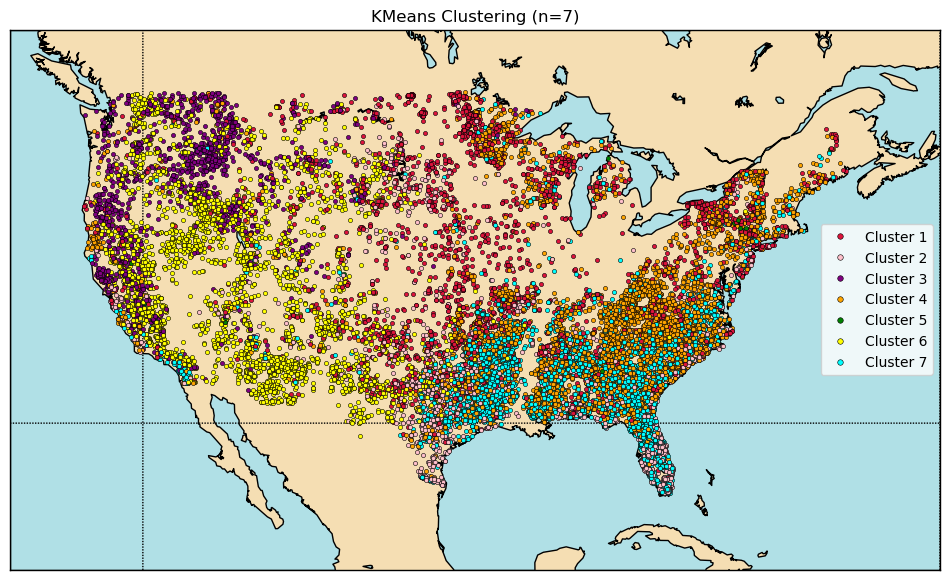

In [7]:
# Spatially plot the forest fire data, clustered from our kmeans analysis
plt.figure(figsize=(12, 8))
m = Basemap(projection='merc',lon_0=-100,resolution='l',lat_0=40, llcrnrlon=-130, llcrnrlat=20, urcrnrlon=-60, urcrnrlat=52)
m.drawcoastlines()
m.fillcontinents(color='wheat',lake_color='powderblue')
# draw parallels and meridians.
m.drawparallels(np.arange(-90.,120.,30.))
m.drawmeridians(np.arange(0.,360.,60.))
m.drawmapboundary(fill_color='powderblue') 

plt.title(f"KMeans Clustering (n={n_k})")

for i in range(len(loc_df)):
    lat = float(loc_df.iloc[i, 0])
    lon = float(loc_df.iloc[i, 1])
    xpt,ypt = m(lon,lat)
    fire_type = int(forest_fires.iloc[i, 15])
    m.plot(xpt, ypt,'o', markersize='3', color=colors_toplot[i], markeredgewidth = '0.4', markeredgecolor="#000000")

custom_handles = [
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[0], markersize=4, label='Cluster 1', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[1], markersize=4, label='Cluster 2', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[2], markersize=4, label='Cluster 3', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[3], markersize=4, label='Cluster 4', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[4], markersize=4, label='Cluster 5', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[5], markersize=4, label='Cluster 6', linestyle='None'),
    Line2D([0], [0], marker='o', color='black', markeredgewidth = '0.4', markerfacecolor=colors[6], markersize=4, label='Cluster 7', linestyle='None')
]
plt.legend(handles=custom_handles)
plt.show()



(24637, 15)
[3 3 3 ... 6 2 6]
3832
{0: 448, 1: 322, 2: 988, 3: 318, 4: 3, 5: 1541, 6: 212}
{0: np.int64(3717), 1: np.int64(3168), 2: np.int64(2040), 3: np.int64(7219), 4: np.int64(35), 5: np.int64(3708), 6: np.int64(4750)}
{0: np.float64(0.12052730696798493), 1: np.float64(0.10164141414141414), 2: np.float64(0.4843137254901961), 3: np.float64(0.04405042249619061), 4: np.float64(0.08571428571428572), 5: np.float64(0.4155879180151025), 6: np.float64(0.04463157894736842)}


Text(0.5, 0, 'Cluster')

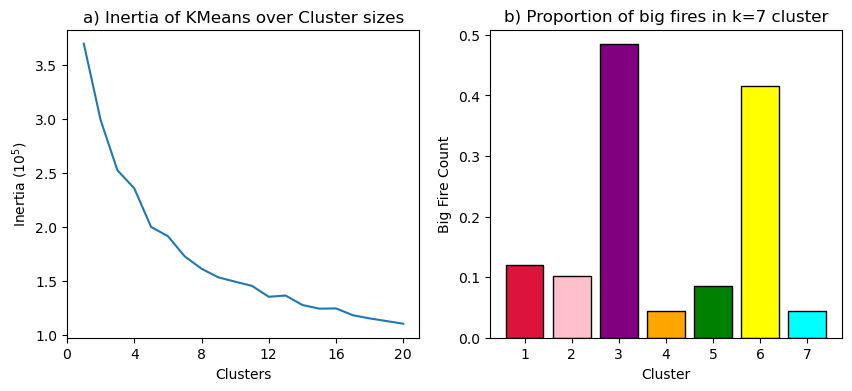

In [9]:
# Create plots for kmeans clustering inertia and the proportion of big fires in each cluster
hist_plot = []
print(kmeans_data.shape)
print(labels)
for i in range(len(labels)):
    if forest_fires.iloc[i, 15] == 1:
        hist_plot.append(labels[i])
print(len(hist_plot))
big_counts = {}
total_counts = {}
big_prop = {}
for c in range(7):
    big_counts[c] = hist_plot.count(c)
    total_counts[c] = np.sum(labels == c)
    big_prop[c] = big_counts[c] / total_counts[c]
print(big_counts)
print(total_counts)
print(big_prop)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(range(1,21), inertia)
ax1.set_title('a) Inertia of KMeans over Cluster sizes')
ax1.set_ylabel('Inertia (10$^5$)')
ax1.set_xlabel('Clusters')
ax1.set_xticks([0,4,8,12,16,20])

ax2.bar([1,2,3,4,5,6,7],[big_prop[0], big_prop[1], big_prop[2], big_prop[3], big_prop[4], big_prop[5], big_prop[6]], color=colors, edgecolor='black')
ax2.set_title('b) Proportion of big fires in k=7 cluster')
ax2.set_ylabel('Big Fire Count')
ax2.set_xlabel('Cluster')
